In [2]:
datafile_lem = np.load('../data/phase_res_2d_dep_lemniscate_20_ions_full_ham_eta_0-03.npz')
datafile_lem_sym = np.load('../data/phase_res_2d_dep_lemniscate_sym_20_ions_full_ham_eta_0-03.npz')

In [3]:
from tdse_solutions import *

In [4]:
def get_inf_arr_from_phase_residuals(phase_res_arr, n_ions):
    n_ions_max = phase_res_arr.shape[2] - 1
    inf_arr = np.zeros((phase_res_arr.shape[0], phase_res_arr.shape[1]))
    
    for i in range(phase_res_arr.shape[0]):
        for j in range(phase_res_arr.shape[1]):
            delta_n = int((n_ions_max - n_ions)/2)
            phase_res = phase_res_arr[i, j]
            if delta_n == 0:
                phase_res_part = phase_res
            else:
                phase_res_part = phase_res[delta_n:-delta_n]
            inf_arr[i, j] = 1 - fidelity_from_phase_residuals(phase_res_part)
    return inf_arr

# $n_{ions}$ dependence for simple lemniscate pulses

In [5]:
delta_a_range = datafile_lem['delta_a_range']
rel_f_range = datafile_lem['rel_f_range']
phase_res_arr = datafile_lem['phase_res_arr']

In [6]:
n_ions_range = range(4, 21, 2)

min_delta_a_range = []
min_rel_f_range = []
min_inf_range_lem = []

for n_ions in n_ions_range:
    inf_arr = get_inf_arr_from_phase_residuals(phase_res_arr, n_ions)
    min_inf = np.min(inf_arr)
    min_i, min_j = np.unravel_index(np.argmin(inf_arr), inf_arr.shape)
    min_delta_a = delta_a_range[min_i]
    min_rel_f = rel_f_range[min_j]

    min_delta_a_range.append(min_delta_a)
    min_rel_f_range.append(min_rel_f)
    min_inf_range_lem.append(min_inf)

Text(0.5, 0, '$n_{ions}$')

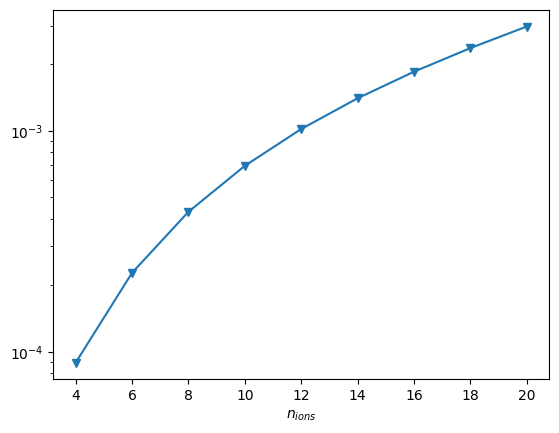

In [7]:
plt.plot(n_ions_range, min_inf_range_lem, marker='v')
plt.yscale('log')
plt.xlabel('$n_{ions}$')

# $n_{ions}$ dependence for lemniscate echoed pulses

In [8]:
delta_a_range = datafile_lem_sym['delta_a_range']
rel_f_range = datafile_lem_sym['rel_f_range']
phase_res_arr = datafile_lem_sym['phase_res_arr']

In [9]:
n_ions_range = range(4, 21, 2)

min_delta_a_range = []
min_rel_f_range = []
min_inf_range_lem_sym = []

for n_ions in n_ions_range:
    inf_arr = get_inf_arr_from_phase_residuals(phase_res_arr, n_ions)
    min_inf = np.min(inf_arr)
    min_i, min_j = np.unravel_index(np.argmin(inf_arr), inf_arr.shape)
    min_delta_a = delta_a_range[min_i]
    min_rel_f = rel_f_range[min_j]

    min_delta_a_range.append(min_delta_a)
    min_rel_f_range.append(min_rel_f)
    min_inf_range_lem_sym.append(min_inf)

Text(0.5, 0, '$n_{ions}$')

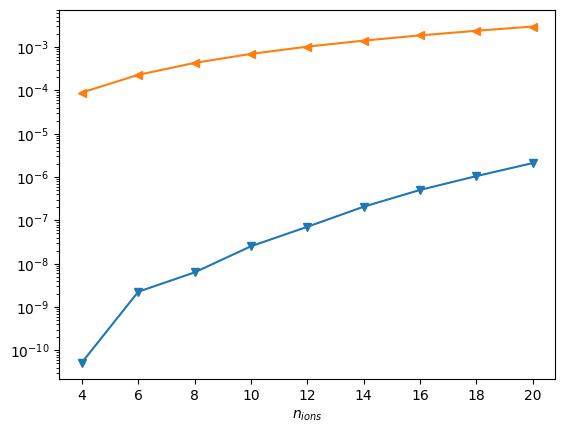

In [10]:
plt.plot(n_ions_range, min_inf_range_lem_sym, marker='v')
plt.plot(n_ions_range, min_inf_range_lem, marker='<')
plt.yscale('log')
plt.xlabel('$n_{ions}$')

# $n_{ions}$ dependence for rectangular pulses

In [11]:
datafile_rect = np.load('../data/phase_res_amplitude_dep_rect_pulse_20_ions_full_ham_eta_0-03.npz')

In [12]:
rel_f_range = datafile_rect['rel_f_range']
n_loops_arr = datafile_rect['n_loops_arr']
phase_res_arr = datafile_rect['phase_res_arr']

In [13]:
min_inf_arr_rect = []
for n_ions in n_ions_range:
    inf_arr = get_inf_arr_from_phase_residuals(phase_res_arr, n_ions)
    min_inf_range = np.min(inf_arr, axis=1)
    min_inf_arr_rect.append(min_inf_range)

min_inf_arr_rect = np.array(min_inf_arr_rect)

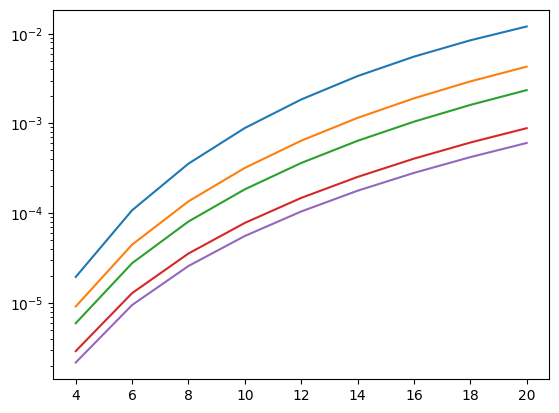

In [14]:
plt.plot(n_ions_range, min_inf_arr_rect)
plt.yscale('log')

# $n_{ions}$ dependence for rectangular echoed pulses

In [15]:
datafile_rect_sym = np.load('../data/phase_res_amplitude_dep_rect_sym_pulse_20_ions_full_ham_eta_0-03.npz')

In [16]:
rel_f_range   = datafile_rect_sym['rel_f_range']
n_loops_arr   = datafile_rect_sym['n_loops_arr']
phase_res_arr = datafile_rect_sym['phase_res_arr']

In [17]:
min_inf_arr_rect_sym = []
for n_ions in n_ions_range:
    inf_arr = get_inf_arr_from_phase_residuals(phase_res_arr, n_ions)
    min_inf_range = np.min(inf_arr, axis=1)
    min_inf_arr_rect_sym.append(min_inf_range)

min_inf_arr_rect_sym = np.array(min_inf_arr_rect_sym)

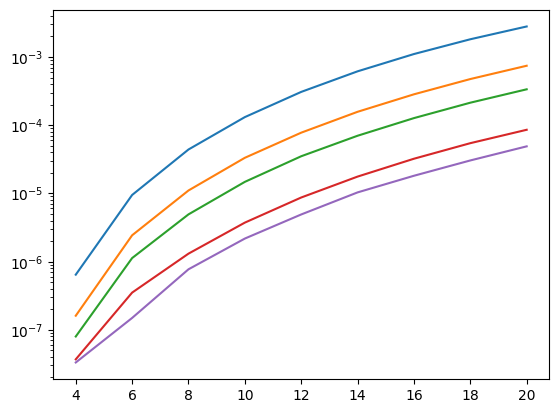

In [18]:
plt.plot(n_ions_range, min_inf_arr_rect_sym)
plt.yscale('log')

# Plot for publication

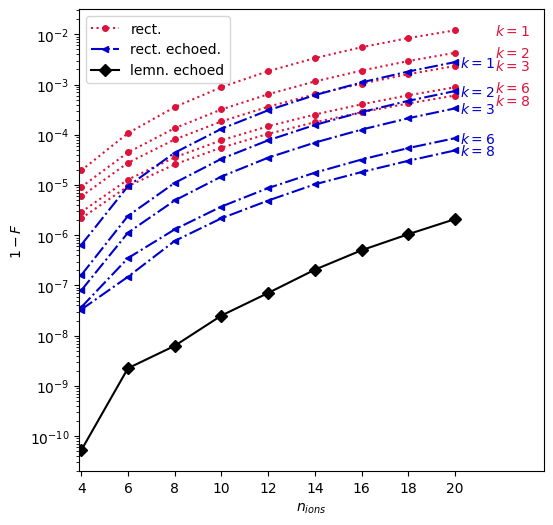

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

#colors_1 = ['gold', 'goldenrod', 'orange', 'darkorange', 'peru']
#colors_2 = ['aquamarine', 'turquoise', 'mediumturquoise', 'lightseagreen', 'teal']

colors_1 = colors_2 = list(matplotlib.colors.BASE_COLORS.keys())

for i, inf_range in enumerate(min_inf_arr_rect.T):
    label = 'rect.' if i == 0 else None
    ax.plot(n_ions_range, inf_range, linestyle=':', 
             color='crimson', marker='o', markersize=4, label=label)#, label=f'rect., $k={n_loops_arr[i]}$')
    
    text_xpos = n_ions_range[-1] + 1.7
    text_ypos =  inf_range[-1]*0.8 if i != 4 else inf_range[-1]*0.63
    ax.text(text_xpos, text_ypos, f'$k={n_loops_arr[i]}$', color='crimson')
#ax.plot(n_ions_range, min_inf_range_lem, color='red', marker='>', label='lemniscate')

for i, inf_range in enumerate(min_inf_arr_rect_sym.T):
    label = 'rect. echoed.' if i == 0 else None
    ax.plot(n_ions_range, inf_range, linestyle='-.', 
             color='mediumblue', marker='<', markersize=4, label=label) #label=f'rect. echoed, $k={n_loops_arr[i]}$')
    ax.text(n_ions_range[-1] + 0.2, inf_range[-1]*0.8, f'$k={n_loops_arr[i]}$', color='mediumblue')
#plt.plot(n_ions_range, min_inf_arr_rect_sym, color='wheat', linestyle='-')

ax.plot(n_ions_range, min_inf_range_lem_sym, color='k', marker='D', label='lemn. echoed')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e-8)
#plt.margins(x=0)
ax.set_xlim(3.9, 23.8)
ax.set_xlabel('$n_{ions}$')
ax.set_ylabel('$1-F$')
ax.legend(loc='upper left')
ax.set_xticks(range(4,21,2))
#ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))

plt.savefig('../figures/n_ions_dep_all_pulses.pdf')
plt.show()